# Neural SDE para Trayectorias de Vuelo (Notebook Ordenado)

Este notebook esta organizado para ejecutarse de principio a fin y comparar dos variantes de modelo:

- Modelo 3V: Fuel Flow, Speed, Altitude.
- Modelo 6V: las 6 variables del dataset completo.

## Objetivo
Entrenar, probar y visualizar ambos modelos de forma consistente.

## Flujo recomendado
1. Importaciones y configuracion
2. Carga de datos y utilidades
3. Definicion de modelos
4. Entrenamiento
5. Evaluacion cuantitativa
6. Visualizaciones (3V y 6V)

### Guia rapida de ejecucion

Para correr el notebook de forma controlada:

- Ejecuta todas las celdas en orden.
- Si quieres una prueba rapida, baja EPOCHS y NUM_SCENARIOS.
- Si solo quieres un modelo, desactiva TRAIN_MODEL_3V o TRAIN_MODEL_6V.
- Las visualizaciones se apoyan en los modelos entrenados en este mismo flujo.

## Importaciones y semilla reproducible

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt

# Semilla para tener resultados mas reproducibles entre ejecuciones.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Dispositivo de computo
Se prioriza MPS, despues CUDA y por ultimo CPU.

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## Configuracion y rutas de datos
Se usan rutas relativas al repositorio para evitar fallos al mover el proyecto.

In [ ]:
# Directorio raiz del proyecto (asumiendo que este notebook vive en Prediction model/).
repo_root = Path.cwd().resolve().parent

# Archivos fuente de entrenamiento y prueba.
path_train = repo_root / "Data" / "Datasets" / "flight_data.pt"
path_test = repo_root / "Data" / "Datasets" / "flight_data_test.pt"

# Validacion temprana: si falla aqui, evita errores mas adelante.
assert path_train.exists(), f"No existe el archivo de train: {path_train}"
assert path_test.exists(), f"No existe el archivo de test: {path_test}"

print(f"Train: {path_train}")
print(f"Test:  {path_test}")

# Hiperparametros globales para pruebas rapidas.
EPOCHS = 80
DT = 0.005
NUM_SCENARIOS = 100
HIDDEN_DIM = 256
TRAIN_MODEL_3V = True
TRAIN_MODEL_6V = True

Train: /home/edgar/GitHub/StochasticATM/Data/Datasets/flight_data.pt
Test:  /home/edgar/GitHub/StochasticATM/Data/Datasets/flight_data_test.pt


## Utilidades de carga y limpieza
Se eliminan vuelos con NaN para evitar inestabilidad numerica en entrenamiento e inferencia.

In [ ]:
def load_flight_tensors(file_path, device="cpu", feature_indices=None):
    """Carga tensores de vuelo y elimina vuelos con NaNs.

    Args:
        file_path: ruta al .pt con llaves 't', 'y_true', 'stats'.
        device: dispositivo de destino.
        feature_indices: lista de indices de variables a conservar (None = todas).
    """
    # Se carga en CPU y luego se mueve al device para mejor control de memoria.
    data = torch.load(file_path, map_location="cpu")
    t = data["t"].to(device)
    y_true = data["y_true"]
    stats = data.get("stats", {})

    # y_true esperado: [time, flights, features]
    if y_true.dim() != 3:
        raise ValueError(f"Formato inesperado en y_true: {y_true.shape}")

    # Eliminar vuelos completos que contengan al menos un NaN.
    nan_mask = torch.isnan(y_true)
    flights_with_nans = torch.any(nan_mask, dim=(0, 2))
    valid_idx = torch.where(~flights_with_nans)[0]
    y_clean = y_true[:, valid_idx, :]

    # Permite entrenar solo subconjuntos de variables (ej. 3V).
    if feature_indices is not None:
        y_clean = y_clean[:, :, feature_indices]

    y_clean = y_clean.to(device)
    print(
        f"{Path(file_path).name}: {y_clean.shape[1]} vuelos validos, "
        f"{y_clean.shape[0]} pasos, {y_clean.shape[2]} variables"
    )
    return t, y_clean, stats

## Definicion de modelos Neural SDE
Se define una clase base parametrica para crear modelos de 3 y 6 variables con el mismo codigo.

In [5]:
class NeuralSDEBase(nn.Module):
    """Neural SDE parametrica para N variables de estado."""

    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.input_dim = input_dim

        # Entrada de la red = estado + tiempo.
        self.f_net = nn.Sequential(
            nn.Linear(self.input_dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, self.input_dim),
        )

        self.g_net = nn.Sequential(
            nn.Linear(self.input_dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, self.input_dim),
            nn.Sigmoid(),
        )

        self._init_weights()
        self.noise_type = "diagonal"
        self.sde_type = "ito"

    def _init_weights(self):
        def init_linear(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.01)

        self.f_net.apply(init_linear)
        self.g_net.apply(init_linear)

        # Inicializacion suave para evitar dinamicas explosivas al inicio.
        nn.init.constant_(self.f_net[-1].weight, 0.001)
        nn.init.constant_(self.f_net[-1].bias, 0.0)
        nn.init.constant_(self.g_net[-2].weight, 0.001)
        nn.init.constant_(self.g_net[-2].bias, -5.0)

    def _add_time(self, t, y):
        t_val = t.expand(y.size(0), 1) * 10.0
        return torch.cat([y, t_val], dim=1)

    def f(self, t, y):
        return self.f_net(self._add_time(t, y))

    def g(self, t, y):
        # Evita difusion exactamente cero.
        return torch.clamp(self.g_net(self._add_time(t, y)), min=1e-4)


class NeuralSDE3V(NeuralSDEBase):
    def __init__(self, hidden_dim=256):
        super().__init__(input_dim=3, hidden_dim=hidden_dim)


class NeuralSDE6V(NeuralSDEBase):
    def __init__(self, hidden_dim=256):
        super().__init__(input_dim=6, hidden_dim=hidden_dim)

## Funciones de entrenamiento, simulacion y metricas
Estas funciones son reutilizadas por ambos modelos.

In [ ]:
def train_model(model, t, y_true, epochs=80, dt=0.005, lr=1e-2):
    # AdamW + coseno suele comportarse estable para este tipo de entrenamiento.
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5
    )
    criterion = nn.MSELoss()
    y0 = y_true[0]

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        # Reconstruye trayectoria completa a partir del estado inicial y malla temporal.
        pred_y = torchsde.sdeint_adjoint(model, y0, t, dt=dt, method="euler")
        loss = criterion(pred_y, y_true)
        loss.backward()

        # Evita gradientes explosivos.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        scheduler.step()

        if np.isnan(loss.item()):
            print(f"ERROR: loss NaN en epoca {epoch}.")
            break

        if epoch % 20 == 0 or epoch == 1 or epoch == epochs:
            current_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:03d}/{epochs} | Loss: {loss.item():.6f} | LR: {current_lr:.6f}")

    return model


@torch.no_grad()
def simulate_scenarios(model, y0, t_span, num_simulations=100, dt=0.005):
    # Repite el estado inicial para muestrear multiples trayectorias estocasticas.
    model.eval()
    y0_expanded = y0.repeat(num_simulations, 1).to(device)
    t_span = t_span.to(device)
    trajectories = torchsde.sdeint(model, y0_expanded, t_span, method="euler", dt=dt)
    return trajectories.cpu()


def evaluate_mse(model, t_eval, y_eval, dt=0.005):
    """Evalua MSE promedio entre trayectoria predicha y real."""
    model.eval()
    with torch.no_grad():
        y0 = y_eval[0]
        pred = torchsde.sdeint(model, y0, t_eval, method="euler", dt=dt)
        mse = torch.mean((pred - y_eval) ** 2).item()
    return mse

### Notas sobre entrenamiento

- Se usa integracion Euler para mantener el costo computacional bajo.
- El entrenamiento minimiza MSE sobre toda la trayectoria.
- Si aparece inestabilidad, prueba bajar LR o aumentar DT con cuidado.
- El clipping de gradiente ayuda a estabilizar la optimizacion.

## Carga de datasets y creacion de modelos
Se preparan tensores para 3V y 6V y se instancian ambos modelos.

In [ ]:
# Datos de entrenamiento y test para 3 variables (Fuel, Speed, Altitude).
t_train_3v, y_train_3v, stats_train = load_flight_tensors(
    path_train, device=device, feature_indices=[0, 1, 2]
 )
t_test_3v, y_test_3v, stats_test = load_flight_tensors(
    path_test, device=device, feature_indices=[0, 1, 2]
 )

# Datos de entrenamiento y test para 6 variables completas.
t_train_6v, y_train_6v, _ = load_flight_tensors(
    path_train, device=device, feature_indices=None
 )
t_test_6v, y_test_6v, _ = load_flight_tensors(
    path_test, device=device, feature_indices=None
 )

# Diccionario para facilitar entrenamiento/evaluacion por nombre.
models = {
    "3V": NeuralSDE3V(hidden_dim=HIDDEN_DIM).to(device),
    "6V": NeuralSDE6V(hidden_dim=HIDDEN_DIM).to(device),
}

print("Modelos creados:", list(models.keys()))

flight_data.pt: 125 vuelos validos, 200 pasos, 3 variables
flight_data_test.pt: 1 vuelos validos, 200 pasos, 3 variables
flight_data.pt: 125 vuelos validos, 200 pasos, 6 variables
flight_data_test.pt: 1 vuelos validos, 200 pasos, 6 variables
Modelos creados: ['3V', '6V']


## Entrenamiento de modelos
Activa o desactiva cada entrenamiento con TRAIN_MODEL_3V y TRAIN_MODEL_6V.

In [ ]:
trained_models = {}

# Entrenamiento opcional del modelo 3V.
if TRAIN_MODEL_3V:
    print("\nEntrenando modelo 3V...")
    trained_models["3V"] = train_model(
        models["3V"], t_train_3v, y_train_3v, epochs=EPOCHS, dt=DT
    )
else:
    print("Entrenamiento 3V desactivado.")

# Entrenamiento opcional del modelo 6V.
if TRAIN_MODEL_6V:
    print("\nEntrenando modelo 6V...")
    trained_models["6V"] = train_model(
        models["6V"], t_train_6v, y_train_6v, epochs=EPOCHS, dt=DT
    )
else:
    print("Entrenamiento 6V desactivado.")

# Mantener compatibilidad con celdas antiguas que usen trained_model.
trained_model = trained_models.get("3V", models["3V"])
print("\nModelos listos para evaluar:", list(trained_models.keys()))


Entrenando modelo 3V...
Epoch 001/500 | Loss: 0.224977 | LR: 0.010000
Epoch 020/500 | Loss: 0.045646 | LR: 0.009961
Epoch 040/500 | Loss: 0.028666 | LR: 0.009843
Epoch 060/500 | Loss: 0.022465 | LR: 0.009649
Epoch 080/500 | Loss: 0.018011 | LR: 0.009382
Epoch 100/500 | Loss: 0.018277 | LR: 0.009046
Epoch 120/500 | Loss: 0.014989 | LR: 0.008646
Epoch 140/500 | Loss: 0.014657 | LR: 0.008189
Epoch 160/500 | Loss: 0.013893 | LR: 0.007681
Epoch 180/500 | Loss: 0.014783 | LR: 0.007132
Epoch 200/500 | Loss: 0.013701 | LR: 0.006549
Epoch 220/500 | Loss: 0.013438 | LR: 0.005941
Epoch 240/500 | Loss: 0.013342 | LR: 0.005319
Epoch 260/500 | Loss: 0.013281 | LR: 0.004691
Epoch 280/500 | Loss: 0.013247 | LR: 0.004069
Epoch 300/500 | Loss: 0.013220 | LR: 0.003461
Epoch 320/500 | Loss: 0.013200 | LR: 0.002878
Epoch 340/500 | Loss: 0.013182 | LR: 0.002329
Epoch 360/500 | Loss: 0.013173 | LR: 0.001821
Epoch 380/500 | Loss: 0.013163 | LR: 0.001364
Epoch 400/500 | Loss: 0.013157 | LR: 0.000964
Epoch 420

## Evaluacion cuantitativa (MSE)
Se calcula MSE en train y test para los modelos entrenados.

In [ ]:
metrics = []

# MSE de entrenamiento y prueba para 3V.
if "3V" in trained_models:
    mse_train_3v = evaluate_mse(trained_models["3V"], t_train_3v, y_train_3v, dt=DT)
    mse_test_3v = evaluate_mse(trained_models["3V"], t_test_3v, y_test_3v, dt=DT)
    metrics.append(("3V", mse_train_3v, mse_test_3v))

# MSE de entrenamiento y prueba para 6V.
if "6V" in trained_models:
    mse_train_6v = evaluate_mse(trained_models["6V"], t_train_6v, y_train_6v, dt=DT)
    mse_test_6v = evaluate_mse(trained_models["6V"], t_test_6v, y_test_6v, dt=DT)
    metrics.append(("6V", mse_train_6v, mse_test_6v))

if not metrics:
    print("No hay modelos entrenados. Activa TRAIN_MODEL_3V o TRAIN_MODEL_6V.")
else:
    print("\nResumen de MSE")
    print("Modelo | MSE Train | MSE Test")
    print("-" * 34)
    for name, train_mse, test_mse in metrics:
        print(f"{name:>6} | {train_mse:9.6f} | {test_mse:8.6f}")


Resumen de MSE
Modelo | MSE Train | MSE Test
----------------------------------
    3V |  0.013147 | 0.011672
    6V |  0.029934 | 0.017787


### Interpretacion de metricas

- MSE mas bajo implica mejor ajuste medio de trayectoria.
- Compara train vs test para detectar sobreajuste.
- La comparacion 3V vs 6V ayuda a decidir complejidad del modelo segun tu objetivo.

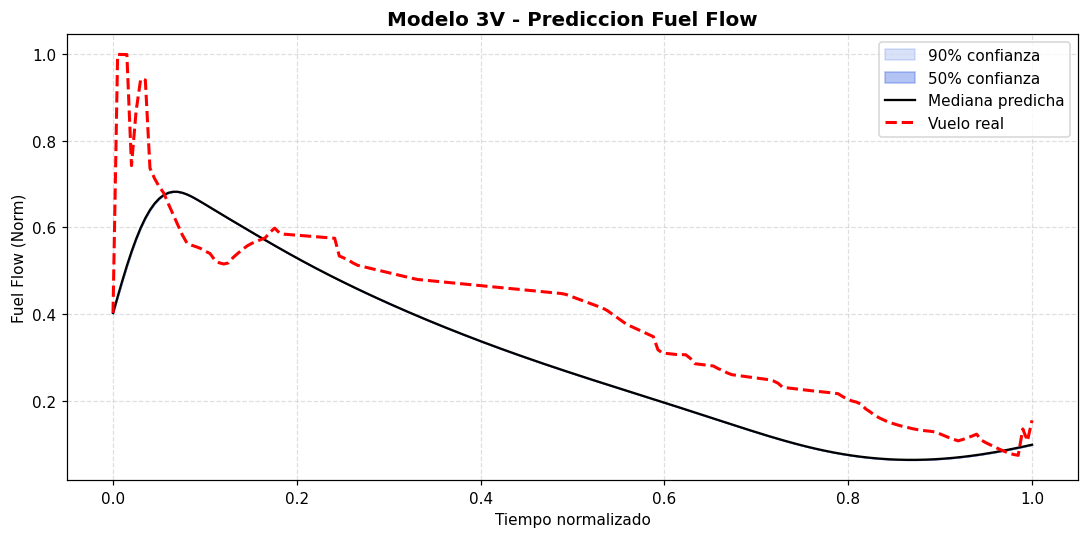

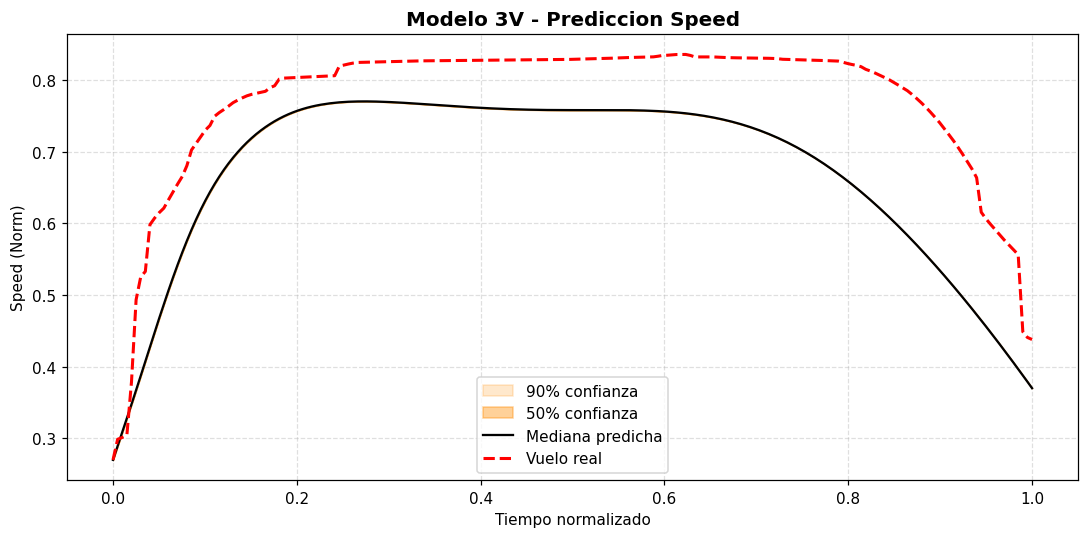

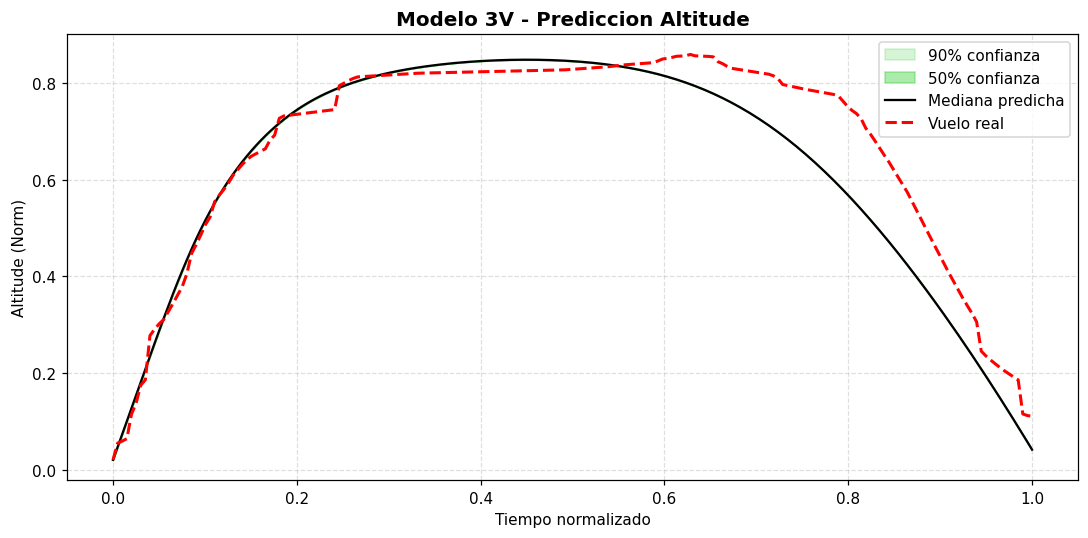

In [ ]:
# Visualizacion de abanico para el modelo 3V.
def plot_fan_chart(trajectories, t_span, y_true, feat_idx, title, ylabel, color):
    # trajectories: [time, simulaciones, features]
    data = trajectories[:, :, feat_idx].numpy()
    t_np = t_span.cpu().numpy()
    true_val = y_true[:, 0, feat_idx].cpu().numpy()

    # Estadisticos del abanico probabilistico.
    median = np.median(data, axis=1)
    p5 = np.percentile(data, 5, axis=1)
    p25 = np.percentile(data, 25, axis=1)
    p75 = np.percentile(data, 75, axis=1)
    p95 = np.percentile(data, 95, axis=1)

    plt.figure(figsize=(10, 5), dpi=110)
    plt.fill_between(t_np, p5, p95, color=color, alpha=0.20, label="90% confianza")
    plt.fill_between(t_np, p25, p75, color=color, alpha=0.40, label="50% confianza")
    plt.plot(t_np, median, color="black", lw=1.5, label="Mediana predicha")
    plt.plot(t_np, true_val, color="red", lw=2, ls="--", label="Vuelo real")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel("Tiempo normalizado")
    plt.ylabel(ylabel)
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

if "3V" in trained_models:
    y0_test_3v = y_test_3v[0]
    trajectories_test_3v = simulate_scenarios(
        trained_models["3V"], y0_test_3v, t_test_3v, num_simulations=NUM_SCENARIOS, dt=DT
    )

    # Una figura por variable principal.
    plot_fan_chart(
        trajectories_test_3v, t_test_3v, y_test_3v, 0,
        "Modelo 3V - Prediccion Fuel Flow", "Fuel Flow (Norm)", "royalblue"
    )
    plot_fan_chart(
        trajectories_test_3v, t_test_3v, y_test_3v, 1,
        "Modelo 3V - Prediccion Speed", "Speed (Norm)", "darkorange"
    )
    plot_fan_chart(
        trajectories_test_3v, t_test_3v, y_test_3v, 2,
        "Modelo 3V - Prediccion Altitude", "Altitude (Norm)", "limegreen"
    )
else:
    print("Modelo 3V no entrenado. Activa TRAIN_MODEL_3V.")

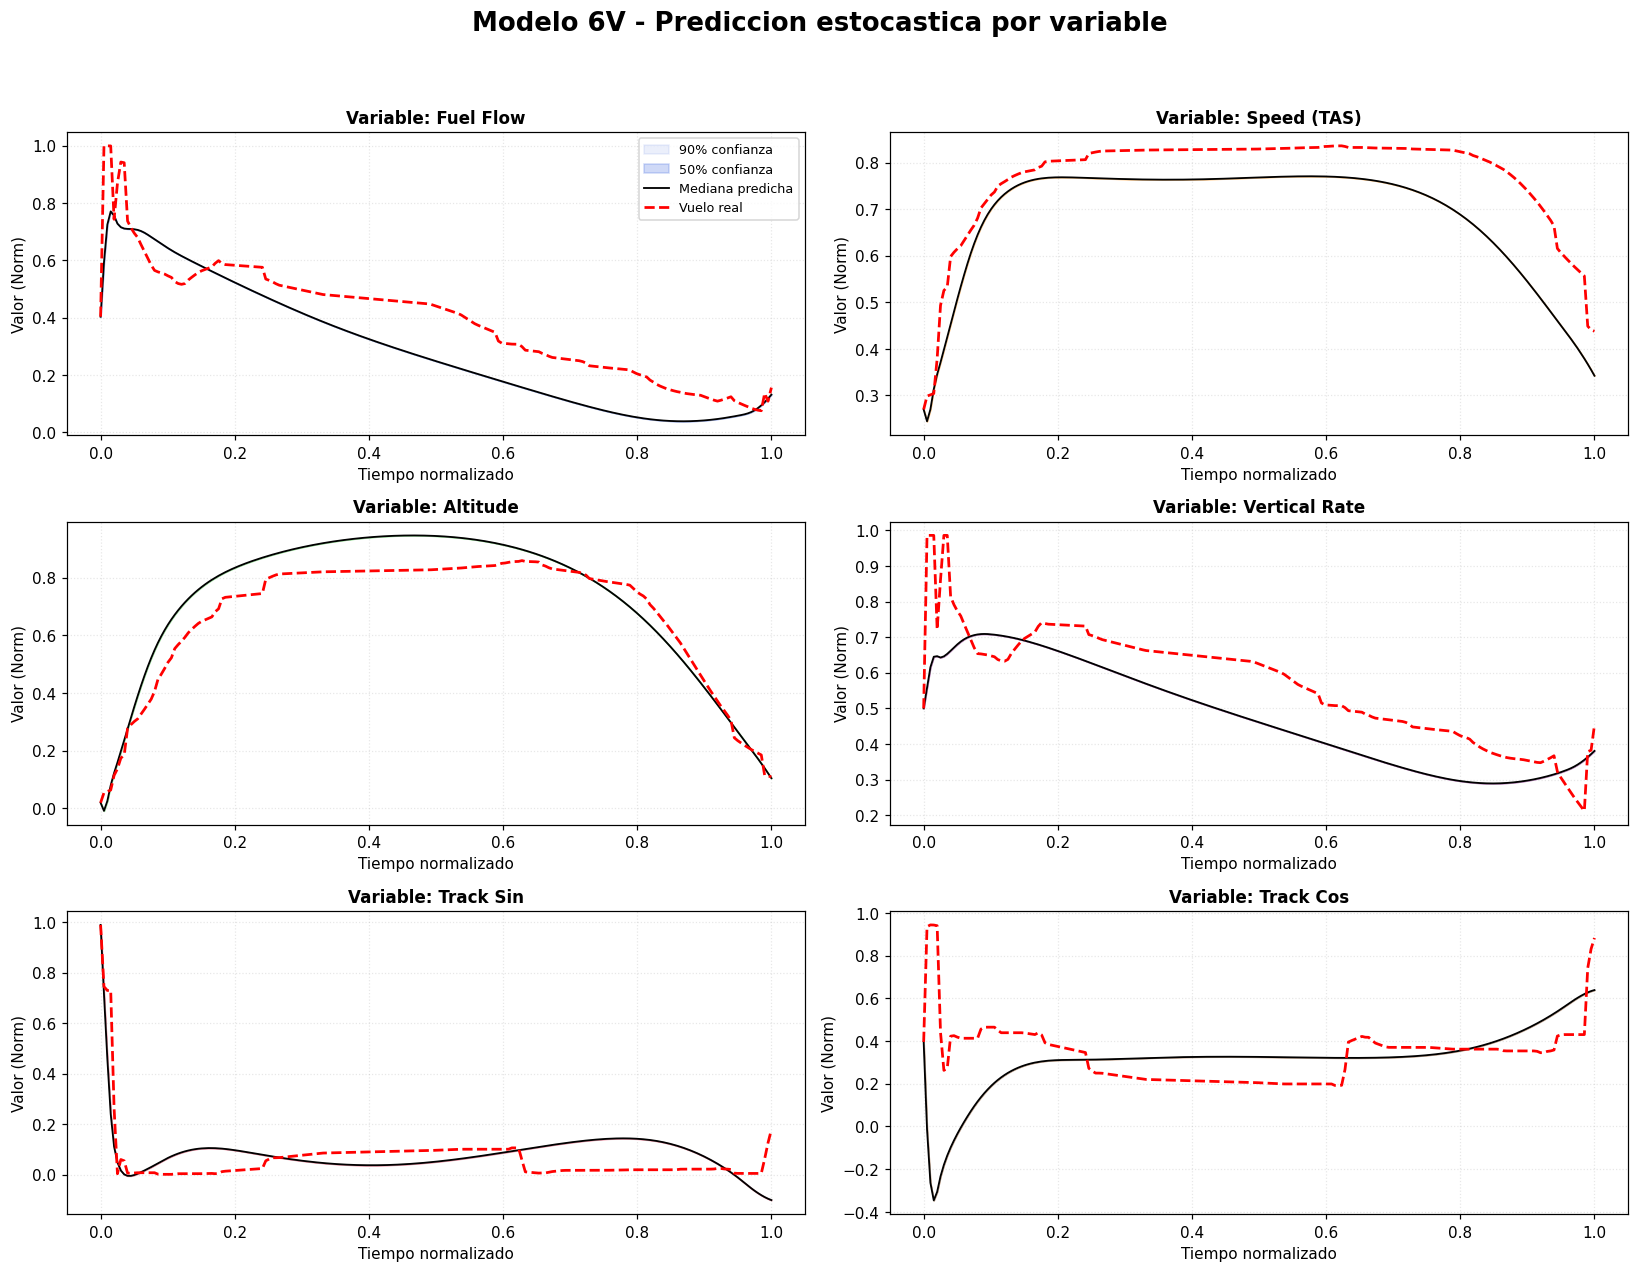

In [ ]:
# Visualizacion de panel completo para el modelo 6V.
def plot_panel_6v(model, t_eval, y_eval, num_sims=100, dt=0.005):
    # Simula multiples escenarios para construir bandas de incertidumbre.
    trajectories = simulate_scenarios(
        model, y_eval[0], t_eval, num_simulations=num_sims, dt=dt
    )

    features = [
        ("Fuel Flow", "royalblue"),
        ("Speed (TAS)", "darkorange"),
        ("Altitude", "limegreen"),
        ("Vertical Rate", "purple"),
        ("Track Sin", "crimson"),
        ("Track Cos", "saddlebrown"),
    ]

    fig, axs = plt.subplots(3, 2, figsize=(15, 12), dpi=110)
    fig.suptitle(
        "Modelo 6V - Prediccion estocastica por variable",
        fontsize=17,
        fontweight="bold",
        y=0.98,
    )

    t_np = t_eval.cpu().numpy()

    for i, (name, color) in enumerate(features):
        row, col = divmod(i, 2)
        ax = axs[row, col]

        sim_data = trajectories[:, :, i].numpy()
        true_data = y_eval[:, 0, i].cpu().numpy()

        median = np.median(sim_data, axis=1)
        p5 = np.percentile(sim_data, 5, axis=1)
        p25 = np.percentile(sim_data, 25, axis=1)
        p75 = np.percentile(sim_data, 75, axis=1)
        p95 = np.percentile(sim_data, 95, axis=1)

        ax.fill_between(t_np, p5, p95, color=color, alpha=0.10, label="90% confianza")
        ax.fill_between(t_np, p25, p75, color=color, alpha=0.25, label="50% confianza")
        ax.plot(t_np, median, color="black", lw=1.2, label="Mediana predicha")
        ax.plot(t_np, true_data, color="red", lw=1.8, ls="--", label="Vuelo real")

        ax.set_title(f"Variable: {name}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Tiempo normalizado")
        ax.set_ylabel("Valor (Norm)")
        ax.grid(True, alpha=0.3, ls=":")
        if i == 0:
            ax.legend(loc="upper right", fontsize="small")

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.show()

if "6V" in trained_models:
    plot_panel_6v(trained_models["6V"], t_test_6v, y_test_6v, num_sims=NUM_SCENARIOS, dt=DT)
else:
    print("Modelo 6V no entrenado. Activa TRAIN_MODEL_6V.")

### Como leer las graficas

- La banda 50% representa el rango central mas probable.
- La banda 90% muestra incertidumbre amplia del proceso estocastico.
- La linea roja es la trayectoria real de referencia.
- Si la roja cae mucho fuera de las bandas, revisa capacidad del modelo o datos.

In [ ]:
# Comparacion adicional: error de los primeros 3 canales entre 3V y 6V en test.
if "3V" in trained_models and "6V" in trained_models:
    with torch.no_grad():
        # Prediccion directa del modelo 3V.
        pred_3v = torchsde.sdeint(
            trained_models["3V"], y_test_3v[0], t_test_3v, method="euler", dt=DT
        )

        # Prediccion del 6V, recortada a las 3 variables comparables.
        pred_6v = torchsde.sdeint(
            trained_models["6V"], y_test_6v[0], t_test_6v, method="euler", dt=DT
        )[:, :, :3]

        mse_3v_first3 = torch.mean((pred_3v - y_test_3v) ** 2).item()
        mse_6v_first3 = torch.mean((pred_6v - y_test_3v) ** 2).item()

    print("Comparacion en test (primeras 3 variables):")
    print(f"MSE modelo 3V: {mse_3v_first3:.6f}")
    print(f"MSE modelo 6V: {mse_6v_first3:.6f}")
else:
    print("Para esta comparacion necesitas entrenar ambos modelos (3V y 6V).")

Comparacion en test (primeras 3 variables):
MSE modelo 3V: 0.011676
MSE modelo 6V: 0.011013
